In [6]:
import h5py
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

files = [
    "003_2006_2080_352_360.nc",
    "004_2006_2080_352_360.nc",
    "005_2006_2080_352_360.nc",
    "006_2006_2080_352_360.nc",
    "007_2006_2080_352_360.nc",
    "008_2006_2080_352_360.nc"
]
datasets = [xr.open_dataset(f) for f in files]
print(f"Number of datasets loaded: {len(datasets)}")

Number of datasets loaded: 6


In [7]:
ds0 = datasets[0]
ds0

<xarray.Dataset> Size: 65MB
Dimensions:     (time: 27374, lat: 11, lon: 6)
Coordinates:
  * time        (time) object 219kB 2006-01-02 00:00:00 ... 2080-12-31 00:00:00
  * lat         (lat) float32 44B 49.48 50.42 51.36 52.3 ... 57.02 57.96 58.9
  * lon         (lon) float32 24B 352.5 353.8 355.0 356.2 357.5 358.8
Data variables:
    TREFMXAV_U  (time, lat, lon) float32 7MB ...
    FLNS        (time, lat, lon) float32 7MB ...
    FSNS        (time, lat, lon) float32 7MB ...
    PRECT       (time, lat, lon) float32 7MB ...
    PRSN        (time, lat, lon) float32 7MB ...
    QBOT        (time, lat, lon) float32 7MB ...
    TREFHT      (time, lat, lon) float32 7MB ...
    UBOT        (time, lat, lon) float32 7MB ...
    VBOT        (time, lat, lon) float32 7MB ...

In [8]:
for var in ds0.data_vars:
    print(f"{var}: {ds0[var].attrs.get('long_name')} ({ds0[var].attrs.get('units')})")

TREFMXAV_U: Urban daily maximum of average 2-m temperature (K)
FLNS: Net longwave flux at surface (W/m2)
FSNS: Net solar flux at surface (W/m2)
PRECT: Total (convective and large-scale) precipitation rate (liq + ice) (m/s)
PRSN: None (None)
QBOT: Lowest model level water vapor mixing ratio (kg/kg)
TREFHT: Reference height temperature (K)
UBOT: Lowest model level zonal wind (m/s)
VBOT: Lowest model level meridional wind (m/s)


In [9]:
# 定义您想要统一使用的 PRSN 详细名称
custom_prsn_name = 'Snow precipitation (liquid-water equivalent) / ms^-1'

# 读取第一个文件作为模板
file_path = '003_2006_2080_352_360.nc'
heading_meanings = {}

with h5py.File(file_path, 'r') as f:
    for var_name in f.keys():
        # 排除辅助维度，只处理数据变量
        if var_name not in ['lat', 'lon', 'time']:
            obj = f[var_name]
            
            # 如果是 PRSN，使用自定义的高级名称；否则从文件读取
            if var_name == 'PRSN':
                heading_meanings[var_name] = custom_prsn_name
            else:
                long_name = obj.attrs.get('long_name', b'Unknown').decode('utf-8')
                units = obj.attrs.get('units', b'').decode('utf-8')
                heading_meanings[var_name] = f"{long_name} ({units})"

# 构建用于后续绘图和展示的元数据 DataFrame
meta_df = pd.DataFrame({
    'Column': list(heading_meanings.keys()), 
    'Meaning': list(heading_meanings.values())
})

# 打印查看结果
print("--- 变量元数据表 (已更新 PRSN 描述) ---")
print(meta_df)

--- 变量元数据表 (已更新 PRSN 描述) ---
       Column                                            Meaning
0  TREFMXAV_U  Urban daily maximum of average 2-m temperature...
1        FLNS                Net longwave flux at surface (W/m2)
2        FSNS                   Net solar flux at surface (W/m2)
3       PRECT  Total (convective and large-scale) precipitati...
4        PRSN  Snow precipitation (liquid-water equivalent) /...
5        QBOT  Lowest model level water vapor mixing ratio (k...
6      TREFHT                   Reference height temperature (K)
7        UBOT                Lowest model level zonal wind (m/s)
8        VBOT           Lowest model level meridional wind (m/s)


Variables to process: ['TREFMXAV_U', 'FLNS', 'FSNS', 'PRECT', 'PRSN', 'QBOT', 'TREFHT', 'UBOT', 'VBOT']


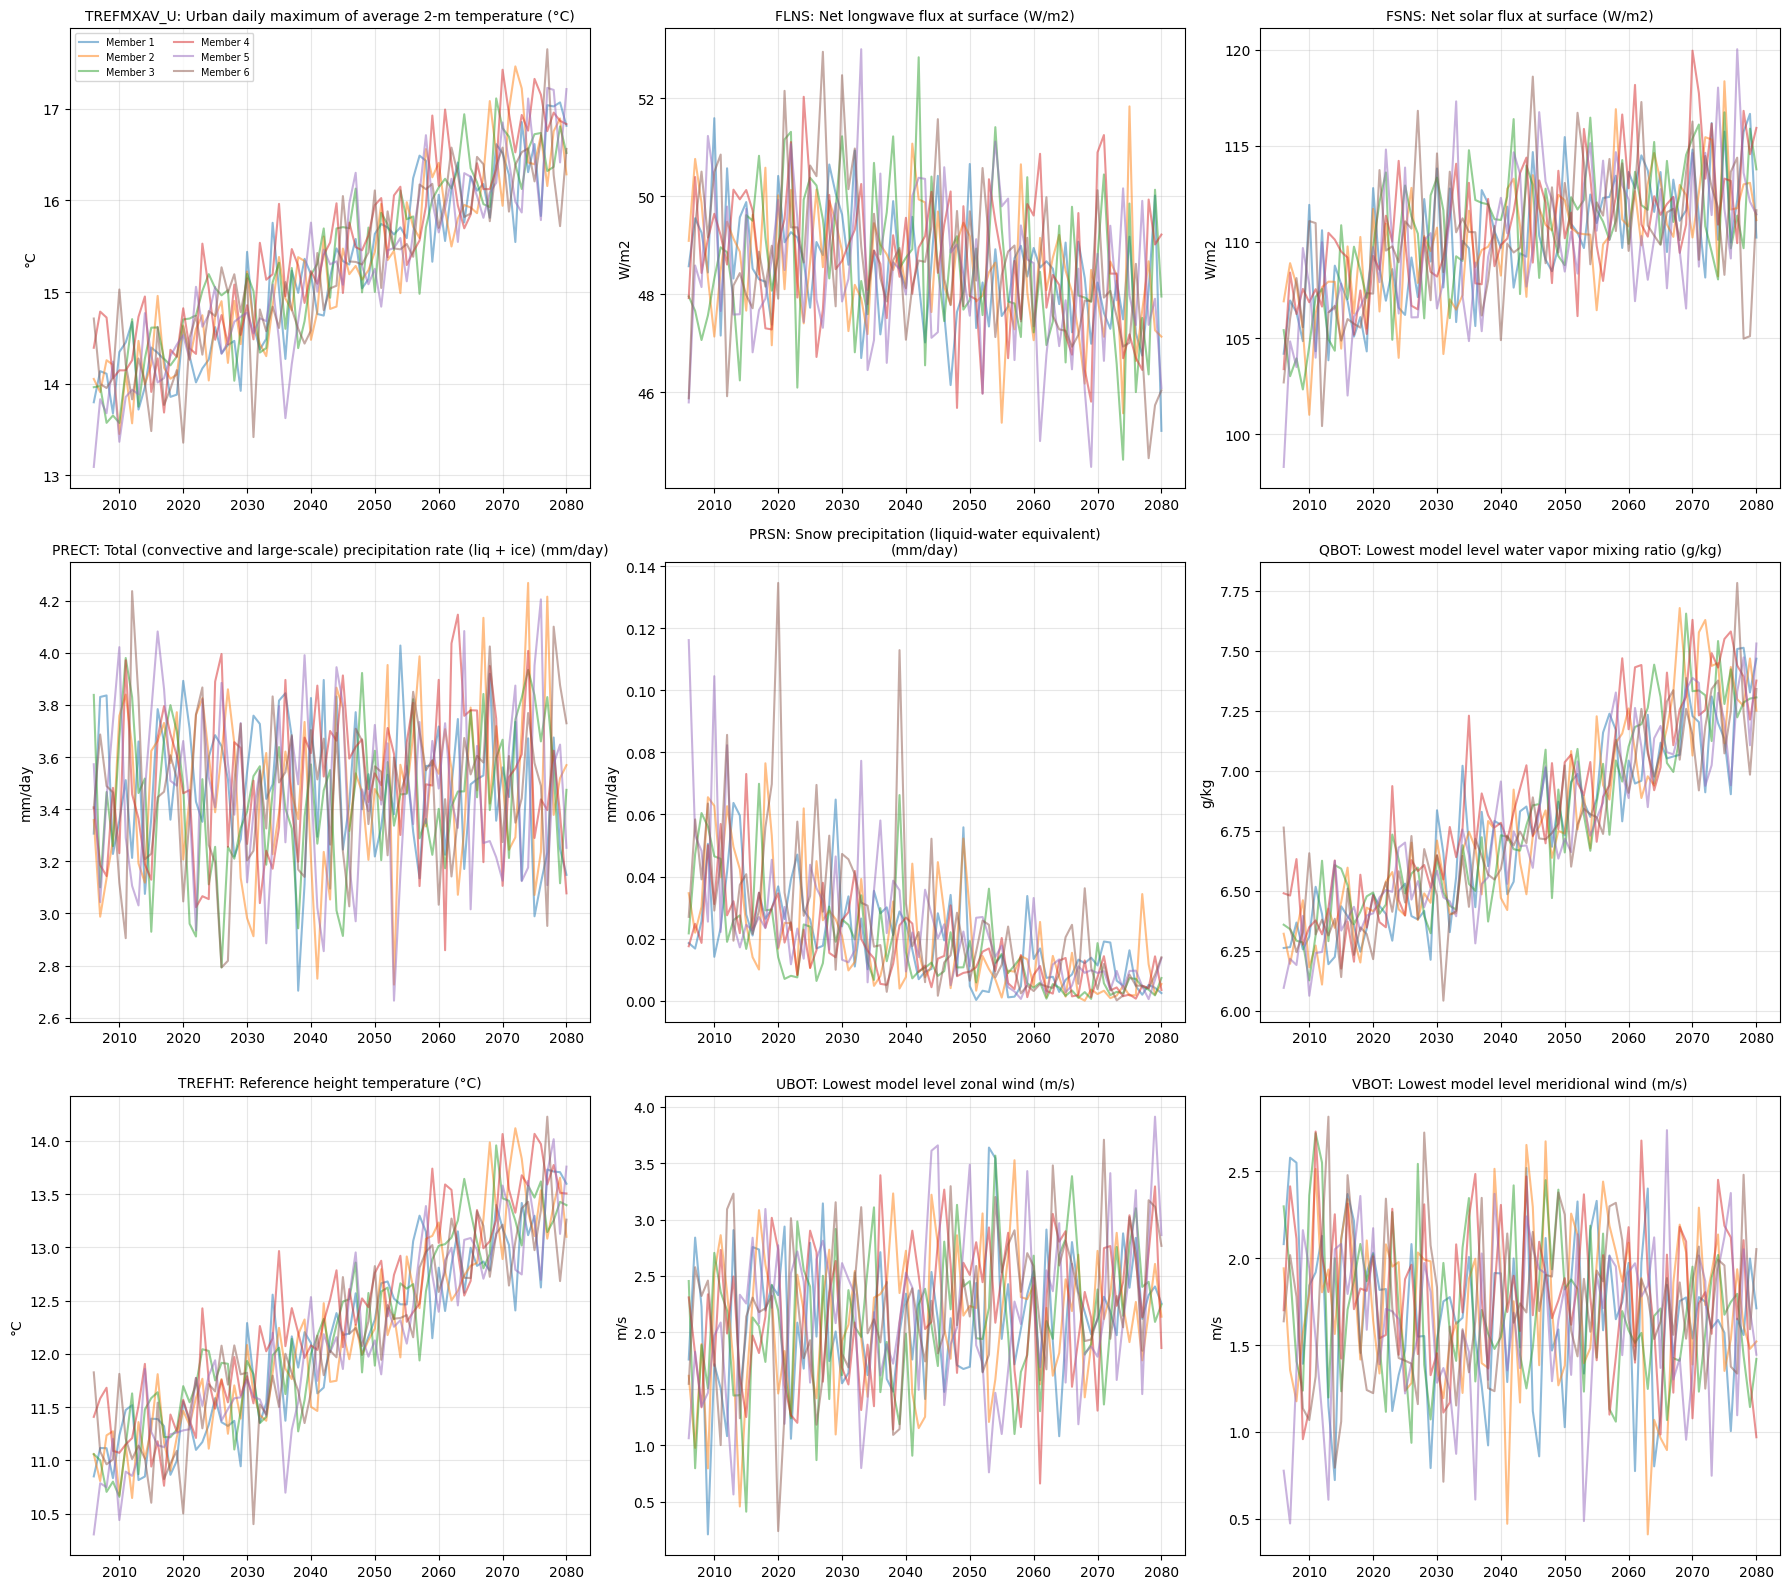

In [23]:
# --- 1. 变量信息提取与 PRSN 命名修改 ---
with h5py.File(files[0], 'r') as f:
    vars_list = [v for v in f.keys() if v not in ['lat', 'lon', 'time', 'time_bounds', 'lat_bounds', 'lon_bounds']]
    var_info = {}
    for v in vars_list:
        if v == 'PRSN':
            # 按照您的要求修改 PRSN 的 long_name
            l_name = "Snow precipitation (liquid-water equivalent)"
        else:
            l_name = f[v].attrs.get('long_name', b'').decode('utf-8') if 'long_name' in f[v].attrs else v
        
        var_info[v] = {
            'long_name': l_name,
            'units': f[v].attrs.get('units', b'').decode('utf-8') if 'units' in f[v].attrs else ''
        }

print("Variables to process:", vars_list)


# --- 2. 物理单位与缩放配置 ---
configs = {
    'TREFHT': {'offset': -273.15, 'scale': 1, 'units': '°C'},
    'TREFMXAV_U': {'offset': -273.15, 'scale': 1, 'units': '°C'},
    'PRECT': {'offset': 0, 'scale': 1000*86400, 'units': 'mm/day'},
    'PRSN': {'offset': 0, 'scale': 1000*86400, 'units': 'mm/day'}, # 单位与 PRECT 对齐
    'QBOT': {'offset': 0, 'scale': 1000, 'units': 'g/kg'},
    'FLNS': {'offset': 0, 'scale': 1, 'units': 'W/m2'},
    'FSNS': {'offset': 0, 'scale': 1, 'units': 'W/m2'},
    'UBOT': {'offset': 0, 'scale': 1, 'units': 'm/s'},
    'VBOT': {'offset': 0, 'scale': 1, 'units': 'm/s'}
}

# 收集数据
results = {}
for v in vars_list:
    cfg = configs.get(v, {'offset': 0, 'scale': 1, 'units': var_info[v]['units']})
    member_data = []
    for f_name in files:
        member_data.append(get_annual_series(f_name, v, offset=cfg['offset'], scale=cfg['scale']))
    results[v] = {
        'data': np.array(member_data),
        'units': cfg['units'],
        'long_name': var_info[v]['long_name']
    }

years = np.arange(2006, 2081)

# --- 3. 绘图 1: 个体成员 (应用新标题格式) ---
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
axes = axes.flatten()

for i, v in enumerate(vars_list):
    ax = axes[i]
    data = results[v]['data']
    for m in range(len(files)):
        ax.plot(years, data[m], alpha=0.5, label=f'Member {m+1}')
    
    # 构造标题: 变量名: 描述 (单位)
    title_text = f"{v}: {results[v]['long_name']} ({results[v]['units']})"
    # 如果是 PRSN，为了美观进行换行处理
    if v == 'PRSN':
        title_text = f"{v}: {results[v]['long_name']}\n({results[v]['units']})"
        
    ax.set_title(title_text, fontsize=10)
    ax.set_ylabel(results[v]['units'])
    ax.grid(True, alpha=0.3)
    if i == 0: ax.legend(fontsize='x-small', ncol=2)

plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.tight_layout()
plt.savefig("eda_all_vars_no_ensemble.png")

     Variable                                        Description  \
0  TREFMXAV_U     Urban daily maximum of average 2-m temperature   
1        FLNS                       Net longwave flux at surface   
2        FSNS                          Net solar flux at surface   
3       PRECT  Total (convective and large-scale) precipitati...   
4        PRSN       Snow precipitation (liquid-water equivalent)   
5        QBOT        Lowest model level water vapor mixing ratio   
6      TREFHT                       Reference height temperature   
7        UBOT                      Lowest model level zonal wind   
8        VBOT                 Lowest model level meridional wind   

   Trend_per_Year  
0        0.039295  
1       -0.018989  
2        0.090677  
3        0.001142  
4       -0.000528  
5        0.015347  
6        0.035731  
7        0.006942  
8       -0.000603  


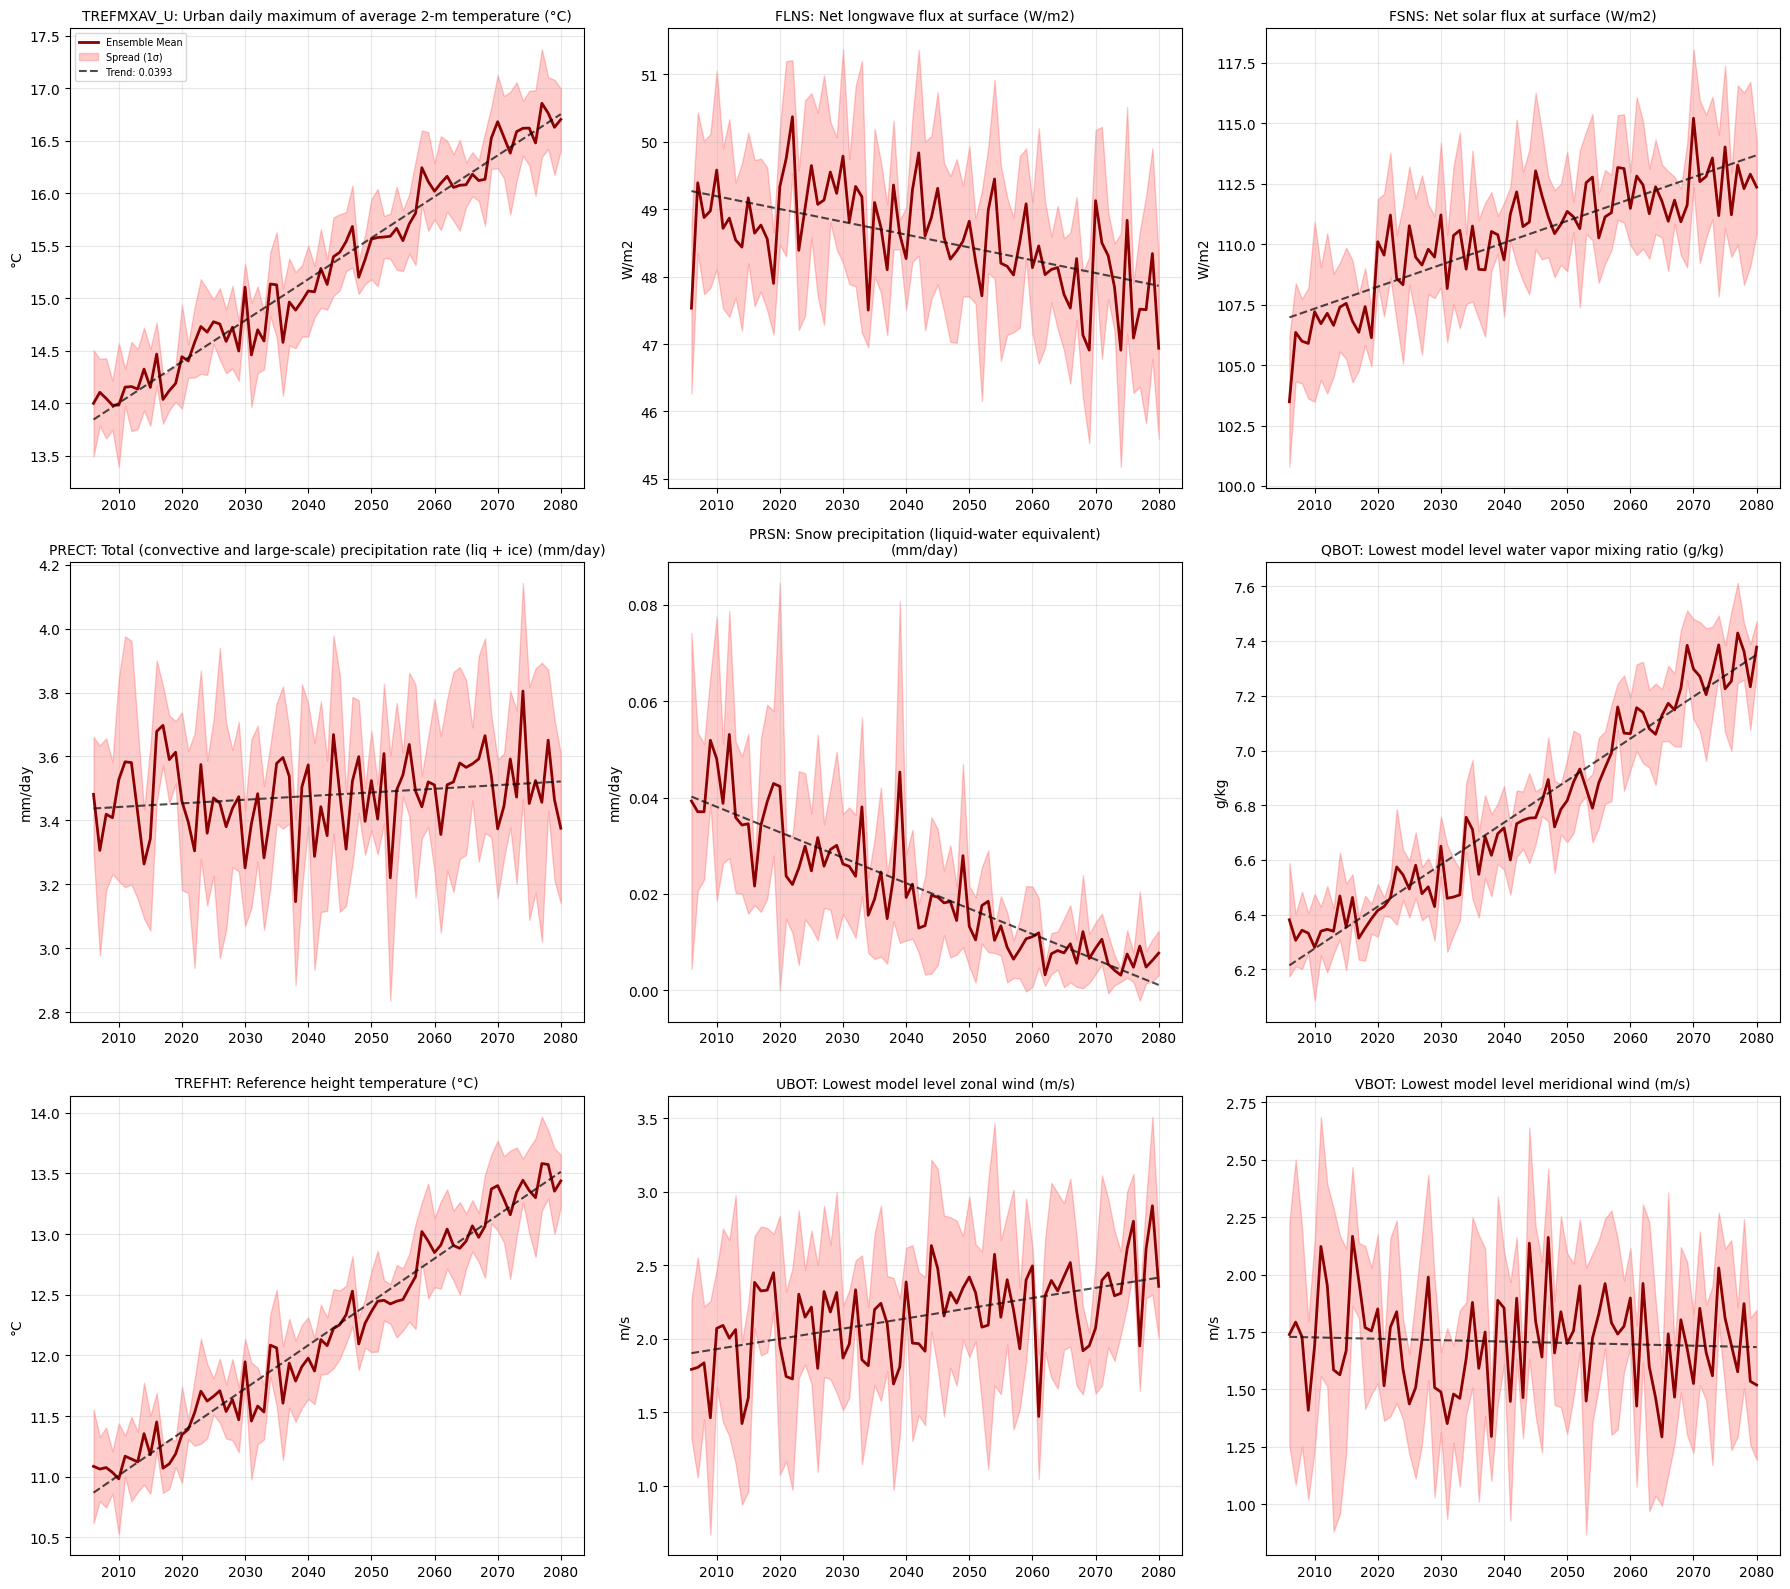

In [12]:
# --- 4. 绘图 2: 集合平均与趋势 (应用新标题格式) ---
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
axes = axes.flatten()

summary_stats = []

for i, v in enumerate(vars_list):
    ax = axes[i]
    data = results[v]['data']
    mean_val = np.nanmean(data, axis=0)
    std_val = np.nanstd(data, axis=0)
    
    ax.plot(years, mean_val, color='darkred', linewidth=2, label='Ensemble Mean')
    ax.fill_between(years, mean_val - std_val, mean_val + std_val, color='red', alpha=0.2, label='Spread (1σ)')
    
    # 计算趋势
    z = np.polyfit(years, mean_val, 1)
    p = np.poly1d(z)
    ax.plot(years, p(years), "k--", alpha=0.7, label=f"Trend: {z[0]:.4f}")
    
    # 标题逻辑同上
    title_text = f"{v}: {results[v]['long_name']} ({results[v]['units']})"
    if v == 'PRSN':
        title_text = f"{v}: {results[v]['long_name']}\n({results[v]['units']})"
        
    ax.set_title(title_text, fontsize=10)
    ax.set_ylabel(results[v]['units'])
    ax.grid(True, alpha=0.3)
    if i == 0: ax.legend(fontsize='x-small')
    
    summary_stats.append({
        'Variable': v,
        'Description': results[v]['long_name'],
        'Units': results[v]['units'],
        'Trend_per_Year': z[0],
        'Mean_2006_2020': np.nanmean(mean_val[:15]),
        'Mean_2066_2080': np.nanmean(mean_val[-15:]),
        'Avg_Spread': np.nanmean(std_val)
    })

plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.tight_layout()
plt.savefig("eda_all_vars_ensemble_mean.png")

# 保存统计摘要
df_summary = pd.DataFrame(summary_stats)
df_summary.to_csv("all_vars_eda_summary.csv", index=False)
print(df_summary[['Variable', 'Description', 'Trend_per_Year']])

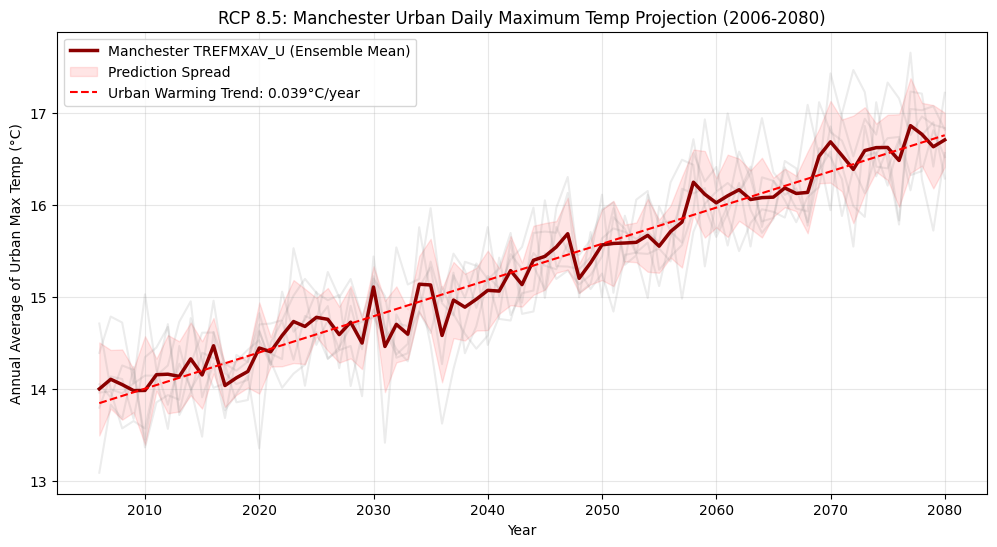

In [35]:
def get_manchester_series_clean(filename, var_name, offset=-273.15, missing_val=1e36):
    with h5py.File(filename, 'r') as f:
        # TREFMXAV_U shape: (27374, 11, 6)
        data = f[var_name][:]
        # Use NaN for missing values
        data[data > 1e30] = np.nan
        # Convert to Celsius
        data = data + offset
        
        n_days = data.shape[0]
        n_years = 75
        annual_mean = []
        annual_max = []
        
        for i in range(n_years):
            start = i * 365
            end = min((i + 1) * 365, n_days)
            if start < n_days:
                year_slice = data[start:end, :, :]
                # Use nanmean and nanmax to avoid missing values
                annual_mean.append(np.nanmean(year_slice))
                annual_max.append(np.nanmax(year_slice))
        return np.array(annual_mean), np.array(annual_max)

all_means = []
all_maxes = []
for f in files:
    m, x = get_manchester_series_clean(f, 'TREFMXAV_U')
    all_means.append(m)
    all_maxes.append(x)

all_means = np.array(all_means)
all_maxes = np.array(all_maxes)

years = np.arange(2006, 2081)
ens_mean_tmax = np.mean(all_means, axis=0)
ens_std_tmax = np.std(all_means, axis=0)

plt.figure(figsize=(12, 6))
for i in range(6):
    plt.plot(years, all_means[i], color='gray', alpha=0.15)
plt.plot(years, ens_mean_tmax, color='darkred', linewidth=2.5, label='Manchester TREFMXAV_U (Ensemble Mean)')
plt.fill_between(years, ens_mean_tmax - ens_std_tmax, ens_mean_tmax + ens_std_tmax, color='red', alpha=0.1, label='Prediction Spread')
z = np.polyfit(years, ens_mean_tmax, 1)
plt.plot(years, np.poly1d(z)(years), "r--", label=f"Urban Warming Trend: {z[0]:.3f}°C/year")
plt.title("RCP 8.5: Manchester Urban Daily Maximum Temp Projection (2006-2080)")
plt.xlabel("Year")
plt.ylabel("Annual Average of Urban Max Temp (°C)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("manchester_urban_temp_prediction.png")

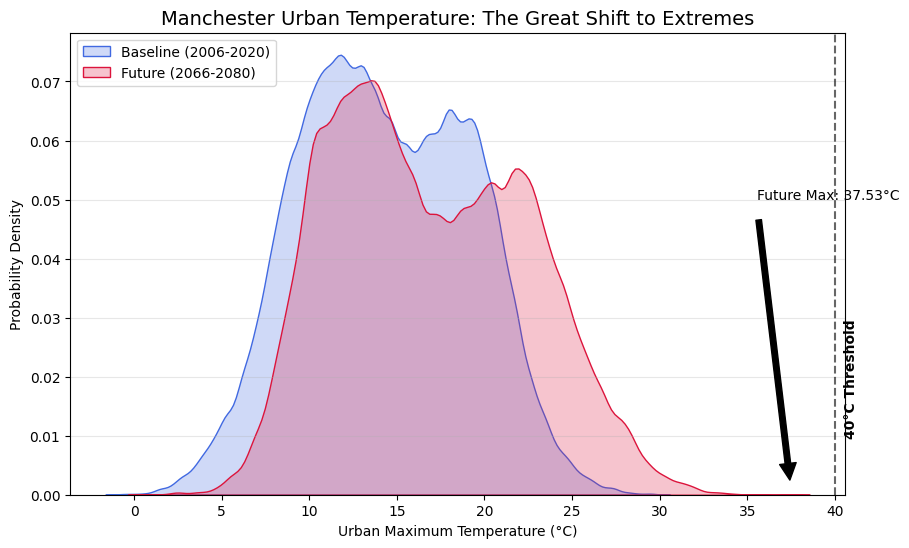

In [29]:
# 曼彻斯特格点
LAT_IDX, LON_IDX = 5, 3

def get_period_data(files):
    base_data, future_data = [], []
    for f_name in files:
        with h5py.File(f_name, 'r') as f:
            d = f['TREFMXAV_U'][:, LAT_IDX, LON_IDX] - 273.15
            d = d[~np.isnan(d) & (d < 1e30)]
            # 提取基准期 (前15年) 和 远期 (最后15年)
            base_data.extend(d[0 : 15*365])
            future_data.extend(d[-15*365 : ])
    return np.array(base_data), np.array(future_data)

base, future = get_period_data(files)

# 开始绘图
plt.figure(figsize=(10, 6))
sns.kdeplot(base, fill=True, color="royalblue", label="Baseline (2006-2020)", bw_adjust=0.5)
sns.kdeplot(future, fill=True, color="crimson", label="Future (2066-2080)", bw_adjust=0.5)

# 标注 40°C 临界线
plt.axvline(40, color='black', linestyle='--', alpha=0.6)
plt.text(40.5, 0.01, '40°C Threshold', rotation=90, color='black', fontweight='bold')

# 标注峰值
plt.annotate(f'Future Max: {np.max(future):.2f}°C', xy=(np.max(future), 0), 
             xytext=(np.max(future)-2, 0.05), arrowprops=dict(facecolor='black', shrink=0.05))

plt.title("Manchester Urban Temperature: The Great Shift to Extremes", fontsize=14)
plt.xlabel("Urban Maximum Temperature (°C)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig("manchester_extreme_shift_pdf.png")

Manchester Baseline (2006-2020) Max: 38.10°C
Manchester Future (2066-2080) Max: 42.69°C
Manchester Warming Trend (Slope): 0.0393 °C/year


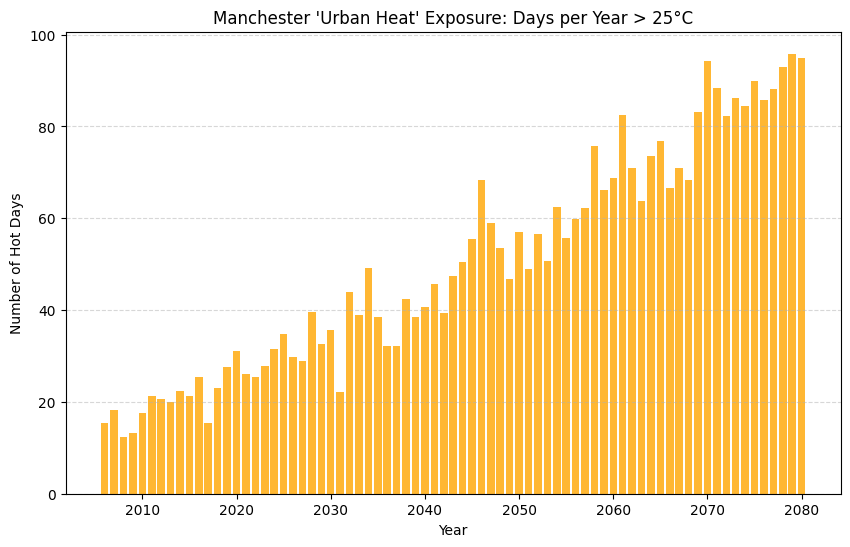

In [31]:
# Threshold analysis
threshold = 25 # Threshold for a hot day in a city like Manchester
exceedance_days = []
for f_idx, f_name in enumerate(files):
    counts_f = []
    with h5py.File(f_name, 'r') as f:
        data = f['TREFMXAV_U'][:]
        data[data > 1e30] = np.nan
        data = data - 273.15
        for yr_idx in range(75):
            start = yr_idx * 365
            end = (yr_idx + 1) * 365
            if start < data.shape[0]:
                year_data = data[start:end, :, :]
                # Number of days in the year where spatial max exceeds threshold
                # Each grid cell could be part of Greater Manchester
                exceed_count = np.sum(np.nanmax(year_data, axis=(1,2)) > threshold)
                counts_f.append(exceed_count)
    exceedance_days.append(counts_f)

exceed_ens = np.mean(exceedance_days, axis=0)

plt.figure(figsize=(10, 6))
plt.bar(years, exceed_ens, color='orange', alpha=0.8)
plt.title(f"Manchester 'Urban Heat' Exposure: Days per Year > {threshold}°C")
plt.xlabel("Year")
plt.ylabel("Number of Hot Days")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig("manchester_heat_days.png")

print(f"Manchester Baseline (2006-2020) Max: {np.nanmax(all_maxes[:, :15]):.2f}°C")
print(f"Manchester Future (2066-2080) Max: {np.nanmax(all_maxes[:, -15:]):.2f}°C")
print(f"Manchester Warming Trend (Slope): {z[0]:.4f} °C/year")

# Save detailed results
summary_manchester = pd.DataFrame({
    'Year': years,
    'Ensemble_Mean_TREFMXAV_U': ens_mean_tmax,
    'Ensemble_Std': ens_std_tmax,
    'Exceed_Days_25C': exceed_ens
})
summary_manchester.to_csv("manchester_urban_analysis_final.csv", index=False)

Loading TREFMXAV_U for all members...
Average Spread: 2.0499 °C
Spread Trend: 0.001879 °C/yr


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


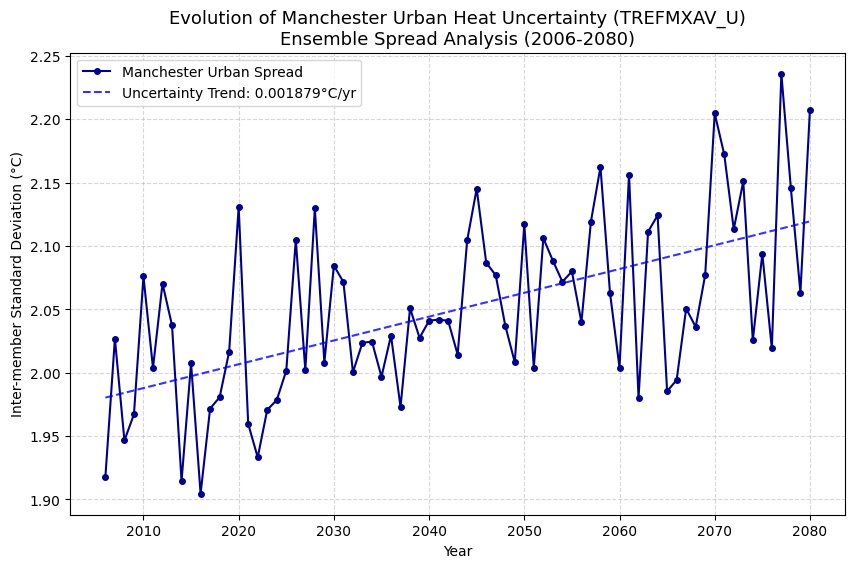

In [16]:

def get_full_data_u(filename, var_name='TREFMXAV_U', offset=-273.15):
    with h5py.File(filename, 'r') as f:
        data = f[var_name][:]
        data[data > 1e30] = np.nan
        return data + offset

# Load all data for TREFMXAV_U
print("Loading TREFMXAV_U for all members...")
all_data_u = []
for f in files:
    all_data_u.append(get_full_data_u(f))

all_data_u = np.array(all_data_u) # Shape: (6, 27374, 11, 6)

# 1. Temporal Evolution of Spread (Prediction Uncertainty)
years = np.arange(2006, 2081)
annual_spread_u = []

for year_idx in range(75):
    start = year_idx * 365
    end = (year_idx + 1) * 365
    # Calculate std across 6 members for this year's data
    # We take the mean of the daily spatial spreads
    year_data = all_data_u[:, start:end, :, :]
    # std across members (axis 0), then mean over time/space
    spread = np.nanmean(np.nanstd(year_data, axis=0))
    annual_spread_u.append(spread)

plt.figure(figsize=(10, 6))
plt.plot(years, annual_spread_u, color='darkblue', marker='o', markersize=4, linestyle='-', label='Manchester Urban Spread')
z_spread = np.polyfit(years, annual_spread_u, 1)
p_spread = np.poly1d(z_spread)
plt.plot(years, p_spread(years), "b--", alpha=0.8, label=f"Uncertainty Trend: {z_spread[0]:.6f}°C/yr")

plt.title("Evolution of Manchester Urban Heat Uncertainty (TREFMXAV_U)\nEnsemble Spread Analysis (2006-2080)", fontsize=13)
plt.xlabel("Year")
plt.ylabel("Inter-member Standard Deviation (°C)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.savefig("manchester_urban_spread_evolution.png")
# Summary for user
print(f"Average Spread: {np.mean(annual_spread_u):.4f} °C")
print(f"Spread Trend: {z_spread[0]:.6f} °C/yr")

Manchester Baseline Urban Max P95 (2006-2020): 21.69°C
Urban Warming Emergence (SNR > 1): 2016


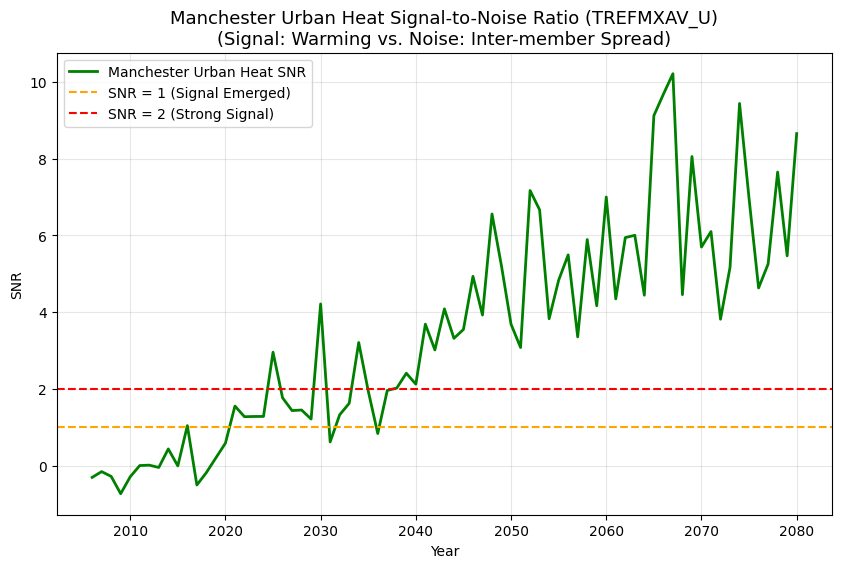

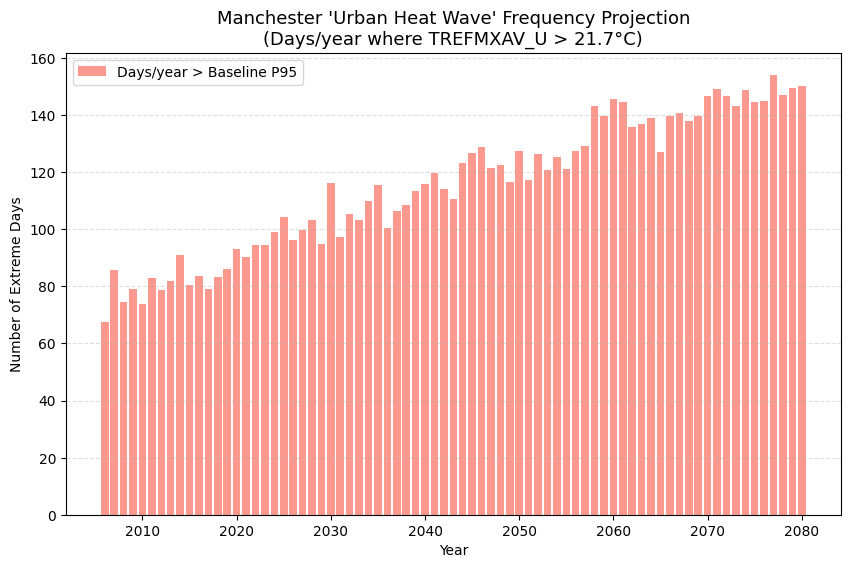

In [17]:
def get_annual_series_u(filename, var_name='TREFMXAV_U', offset=-273.15):
    with h5py.File(filename, 'r') as f:
        data = f[var_name][:]
        data[data > 1e30] = np.nan
        data = data + offset
        n_days = data.shape[0]
        annual_means = []
        for i in range(75):
            start = i * 365
            end = (i + 1) * 365
            if start < n_days:
                annual_means.append(np.nanmean(data[start:end, :, :]))
        return np.array(annual_means)

all_series_u = np.array([get_annual_series_u(f) for f in files]) # (6, 75)
ens_mean_u = np.mean(all_series_u, axis=0)
ens_std_u = np.std(all_series_u, axis=0) # Noise

years = np.arange(2006, 2081)

# 3. Signal-to-Noise Ratio (SNR) Analysis
# Baseline: first 15 years
baseline_u = np.mean(ens_mean_u[:15])
signal_u = ens_mean_u - baseline_u
# Use rolling noise to stabilize? Or just annual std?
# Annual std is quite variable, let's use the average std as the 'Noise floor'
noise_floor = np.mean(ens_std_u)
snr_u = signal_u / ens_std_u

plt.figure(figsize=(10, 6))
plt.plot(years, snr_u, color='green', linewidth=2, label='Manchester Urban Heat SNR')
plt.axhline(1, color='orange', linestyle='--', label='SNR = 1 (Signal Emerged)')
plt.axhline(2, color='red', linestyle='--', label='SNR = 2 (Strong Signal)')
plt.title("Manchester Urban Heat Signal-to-Noise Ratio (TREFMXAV_U)\n(Signal: Warming vs. Noise: Inter-member Spread)", fontsize=13)
plt.xlabel("Year")
plt.ylabel("SNR")
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig("manchester_urban_snr_evolution.png")

# 4. Extreme Threshold Analysis (New Normal)
# Let's see how many days each member has above a high baseline threshold
# Baseline P95 threshold from 2006-2020
all_daily_data = []
for f_name in files:
    with h5py.File(f_name, 'r') as f:
        data = f['TREFMXAV_U'][:5475, :, :] # First 15 years (approx)
        data[data > 1e30] = np.nan
        all_daily_data.append((data - 273.15).flatten())

baseline_p95_u = np.nanpercentile(np.concatenate(all_daily_data), 95)
print(f"Manchester Baseline Urban Max P95 (2006-2020): {baseline_p95_u:.2f}°C")

# Calculate yearly days exceeding this for all members
days_exceeding_list = []
for f_name in files:
    counts = []
    with h5py.File(f_name, 'r') as f:
        data = f['TREFMXAV_U'][:] - 273.15
        data[data > 1e30] = np.nan
        for yr in range(75):
            start = yr * 365
            end = (yr + 1) * 365
            if start < data.shape[0]:
                yr_data = data[start:end, :, :]
                # Average number of urban cells exceeding threshold per day? 
                # Or any urban cell exceeding threshold in the domain for that day?
                # Let's go with: Daily max across domain exceeds threshold
                daily_max = np.nanmax(yr_data, axis=(1, 2))
                counts.append(np.sum(daily_max > baseline_p95_u))
    days_exceeding_list.append(counts)

days_exceeding_ens = np.mean(days_exceeding_list, axis=0)

plt.figure(figsize=(10, 6))
plt.bar(years, days_exceeding_ens, color='salmon', alpha=0.8, label='Days/year > Baseline P95')
plt.title(f"Manchester 'Urban Heat Wave' Frequency Projection\n(Days/year where TREFMXAV_U > {baseline_p95_u:.1f}°C)", fontsize=13)
plt.xlabel("Year")
plt.ylabel("Number of Extreme Days")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend()
plt.savefig("manchester_urban_extreme_frequency.png")

# Emergence detection
years_snr1 = years[np.where(snr_u > 1)[0]]
emerge_year = years_snr1[0] if len(years_snr1) > 0 else "N/A"
print(f"Urban Warming Emergence (SNR > 1): {emerge_year}")

# Final summary data
summary_final = pd.DataFrame({
    'Year': years,
    'Ensemble_Mean': ens_mean_u,
    'Ensemble_Spread': ens_std_u,
    'SNR': snr_u,
    'Extreme_Days': days_exceeding_ens
})
summary_final.to_csv("manchester_urban_final_eda_results.csv", index=False)

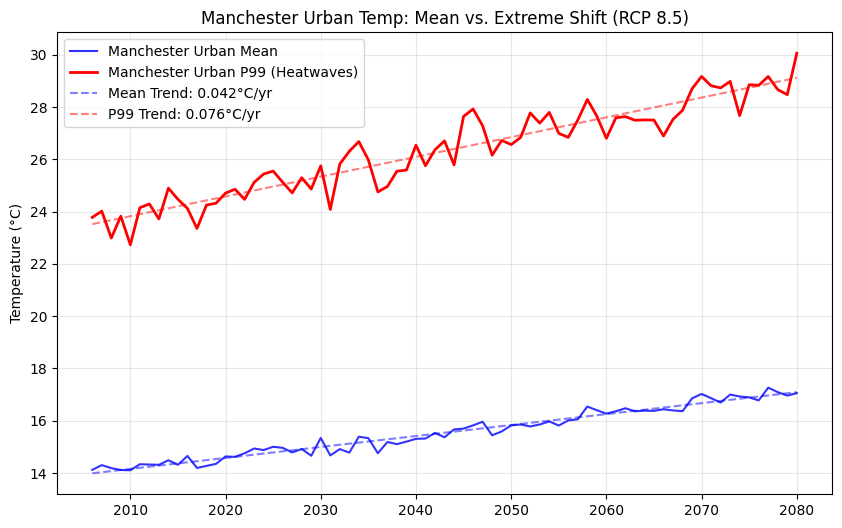

In [27]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

files = ["003_2006_2080_352_360.nc", "004_2006_2080_352_360.nc", 
         "005_2006_2080_352_360.nc", "006_2006_2080_352_360.nc", 
         "007_2006_2080_352_360.nc", "008_2006_2080_352_360.nc"]

# 锁定曼彻斯特格点
LAT_IDX, LON_IDX = 5, 3

def get_manchester_urban_stats(filename):
    with h5py.File(filename, 'r') as f:
        # 提取城市变量并清洗
        data = f['TREFMXAV_U'][:, LAT_IDX, LON_IDX]
        data[data > 1e30] = np.nan
        data = data - 273.15  # 转换为摄氏度
        
        n_days = data.shape[0]
        a_mean, a_p99, a_p95 = [], [], []
        
        for i in range(75):
            year_data = data[i*365 : (i+1)*365]
            valid = year_data[~np.isnan(year_data)]
            if len(valid) > 0:
                a_mean.append(np.mean(valid))
                a_p99.append(np.percentile(valid, 99))
                a_p95.append(np.percentile(valid, 95))
        return np.array(a_mean), np.array(a_p99), np.array(a_p95)

# --- 数据提取与集合平均 ---
all_means, all_p99s, all_p95s = [], [], []
for f in files:
    m, p99, p95 = get_manchester_urban_stats(f)
    all_means.append(m)
    all_p99s.append(p99)
    all_p95s.append(p95)

ens_mean = np.mean(all_means, axis=0)
ens_p99 = np.mean(all_p99s, axis=0)
ens_p95 = np.mean(all_p95s, axis=0)
years = np.arange(2006, 2081)

# --- 1. 绘图：极端值 vs 均值 ---
plt.figure(figsize=(10, 6))
plt.plot(years, ens_mean, label='Manchester Urban Mean', color='blue', alpha=0.8)
plt.plot(years, ens_p99, label='Manchester Urban P99 (Heatwaves)', color='red', linewidth=2)

# 计算变化率 (斜率)
z1 = np.polyfit(years, ens_mean, 1)
z2 = np.polyfit(years, ens_p99, 1)
plt.plot(years, np.poly1d(z1)(years), "b--", alpha=0.5, label=f"Mean Trend: {z1[0]:.3f}°C/yr")
plt.plot(years, np.poly1d(z2)(years), "r--", alpha=0.5, label=f"P99 Trend: {z2[0]:.3f}°C/yr")

plt.title("Manchester Urban Temp: Mean vs. Extreme Shift (RCP 8.5)")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("manchester_urban_extremes_shift.png")

Calculating Urban Warming Acceleration (15-yr rolling slope)...
Added picture: manchester_urban_acceleration.png


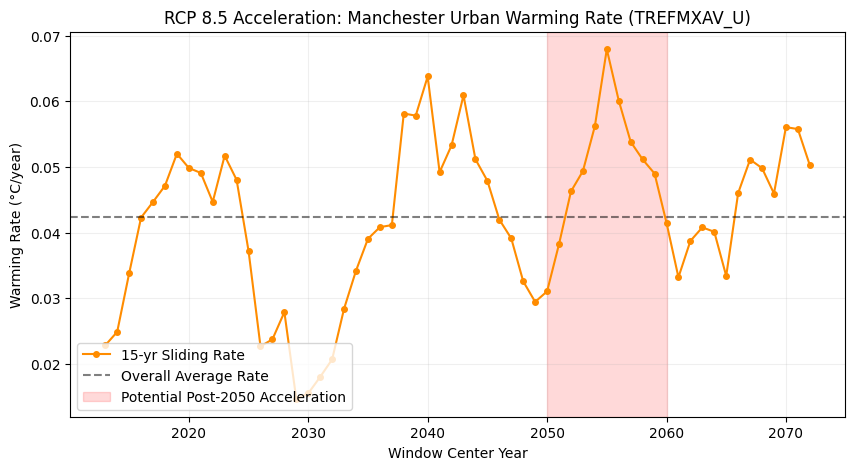

In [25]:
# --- 补全的分析点 2：升温加速度分析 ---
print("Calculating Urban Warming Acceleration (15-yr rolling slope)...")
urban_warming_rates = []
# 计算 rolling 15-year slope of TREFMXAV_U
for i in range(len(years)-15):
    y_window = years[i:i+15]
    # 使用集合平均的城市温均值
    t_window = ens_mean[i:i+15]
    # 计算这15年内的线性斜率
    slope = np.polyfit(y_window, t_window, 1)[0]
    urban_warming_rates.append(slope)

# 绘图：升温速率随时间的变化
plt.figure(figsize=(10, 5))
# 滑动窗口的中心年份
center_years = years[7 : len(years)-8]
plt.plot(center_years, urban_warming_rates, color='darkorange', marker='o', markersize=4, label='15-yr Sliding Rate')

# 标注总体平均速率线
plt.axhline(np.mean(urban_warming_rates), color='black', linestyle='--', alpha=0.5, label='Overall Average Rate')

# 标注 2050 年临界区
plt.axvspan(2050, 2060, color='red', alpha=0.15, label='Potential Post-2050 Acceleration')

plt.title("RCP 8.5 Acceleration: Manchester Urban Warming Rate (TREFMXAV_U)")
plt.xlabel("Window Center Year")
plt.ylabel("Warming Rate (°C/year)")
plt.grid(True, alpha=0.2)
plt.legend(loc='lower left')
plt.savefig("manchester_urban_acceleration.png")

print("Added picture: manchester_urban_acceleration.png")

Manchester Baseline P95 Threshold: 21.81°C


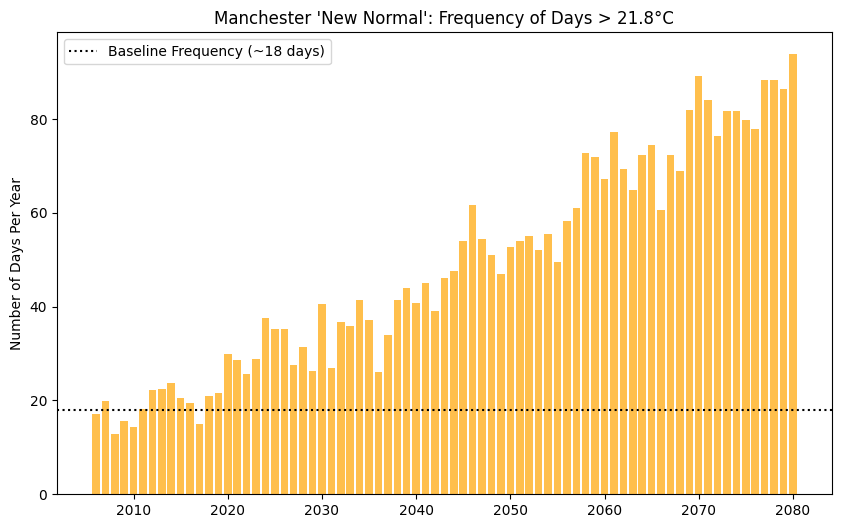

In [26]:
# --- 2. 频率分析 (新常态) ---
# 定义基准期极端阈值
threshold = np.mean(ens_p95[:15]) 
print(f"Manchester Baseline P95 Threshold: {threshold:.2f}°C")

# 计算超过阈值的天数
exceedance = []
for f_idx, f_name in enumerate(files):
    counts_f = []
    with h5py.File(f_name, 'r') as f:
        data = f['TREFMXAV_U'][:, LAT_IDX, LON_IDX] - 273.15
        data[data > 1e30] = np.nan
        for yr in range(75):
            count = np.sum(data[yr*365 : (yr+1)*365] > threshold)
            counts_f.append(count)
    exceedance.append(counts_f)

ens_exceed = np.mean(exceedance, axis=0)

plt.figure(figsize=(10, 6))
plt.bar(years, ens_exceed, color='orange', alpha=0.7)
plt.axhline(18, color='black', linestyle=':', label='Baseline Frequency (~18 days)')
plt.title(f"Manchester 'New Normal': Frequency of Days > {threshold:.1f}°C")
plt.ylabel("Number of Days Per Year")
plt.legend()
plt.savefig("manchester_urban_new_normal.png")